# Análisis y Procesamiento de Señales

## Trabajo Práctico N°5

### Introducción

En esta TS se analizarán distintas señales, como ECG, PPG y audio, con el objetivo de estimar su densidad espectral de potencia (PSD) y su ancho de banda.

Para estimar la PSD se utilizará el método de Welch, utilizando una ventana flattop y analizando distintos valores para la cantidad de muestras de cada segmento. A partir de los espectros obtenidos se estudiará cómo se distribuye la potencia de cada señal en frecuencia y se estimará su ancho de banda.

In [2]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write

from scipy.signal import windows

### ECG

Empezamos analizando la señal de ECG sin ruido. Observando primero la señal en el dominio temporal y luego estime su PSD mediante el método de Welch.

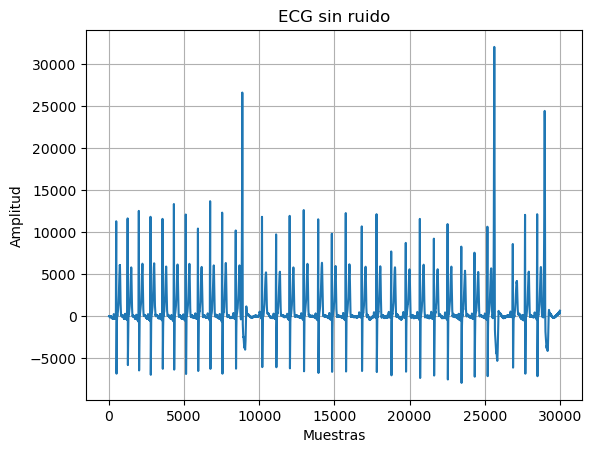

In [3]:
fs_ecg = 1000  # Hz

ecg_one_lead = np.load('ecg_sin_ruido.npy')

plt.figure()
plt.plot(ecg_one_lead)
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.title('ECG sin ruido')
plt.grid()

En el gráfico se observa la señal de ECG sin ruido en el dominio temporal. A partir de esta señal realizo la estimación de su densidad espectral de potencia.

Para aplicar el método de Welch es necesario definir la cantidad de muestras de cada segmento. Para elegir un valor adecuado pobre distintos valores de k, utilizando L=N/k, y compare las PSD obtenidas. Entonces se busca un compromiso entre la resolución en frecuencia y el suavizado de la estimación.

In [4]:
N = 30000

# k = 10
k1 = 10
l1 = N//k1
ventana1 = windows.flattop(l1)

f1, welch1 = sig.welch(ecg_one_lead, fs=fs_ecg, window=ventana1, nperseg=l1, noverlap=l1//2, nfft=N)

# k = 20
k2 = 20
l2 = N//k2
ventana2 = windows.flattop(l2)

f2, welch2 = sig.welch(ecg_one_lead, fs=fs_ecg, window=ventana2, nperseg=l2, noverlap=l2//2, nfft=N)


# k = 35
k3 = 35
l3 = N//k3
ventana3 = windows.flattop(l3)

f3, welch3 = sig.welch(ecg_one_lead, fs=fs_ecg, window=ventana3, nperseg=l3, noverlap=l3//2, nfft=N)

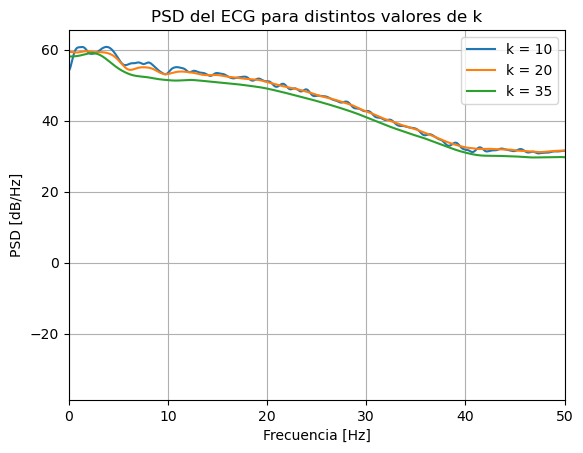

In [5]:
plt.figure()

plt.plot(f1, 10*np.log10(welch1), label='k = 10')
plt.plot(f2, 10*np.log10(welch2), label='k = 20')
plt.plot(f3, 10*np.log10(welch3), label='k = 35')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD del ECG para distintos valores de k')

plt.xlim([0, 50])

plt.grid()
plt.legend()

Al comparar las PSD obtenidas para los distintos valores de k, se observa que las tres presentan un comportamiento similar. Se eligió k=20 ya que permite obtener un equilibrio entre el detalle del espectro y el suavizado de la estimación.

(0.0, 50.0)

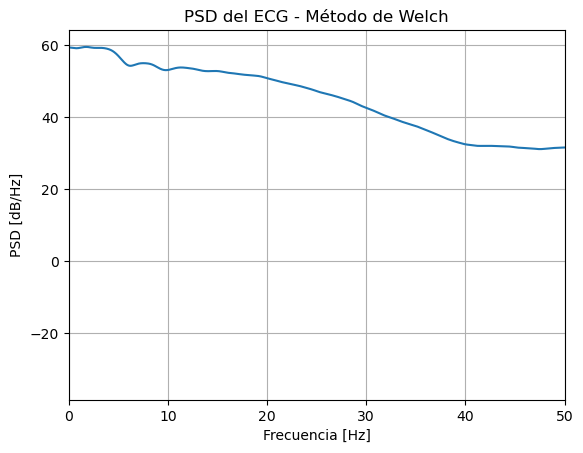

In [6]:
N = len(ecg_one_lead)
k = 20

l = N//k

ventana = windows.flattop(l)

f, welch_ecg = sig.welch(ecg_one_lead,
                         fs=fs_ecg,
                         window=ventana,
                         nperseg=l,
                         noverlap=l//2,
                         nfft=N)

plt.figure()
plt.plot(f, 10*np.log10(welch_ecg))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD del ECG - Método de Welch')
plt.grid()
plt.xlim([0, 50])

En la PSD se observa que la mayor parte de la potencia del ECG se encuentra concentrada en las bajas frecuencias y disminuye a medida que aumenta la frecuencia. Esto corresponde a un comportamiento  pasabajo.

Para estimar el ancho de banda calculo la potencia acumulada a partir de la PSD. Como criterio considero la frecuencia hasta la cual se encuentra acumulado el 99 % de la potencia total de la señal.

In [8]:
pot_total = np.sum(welch_ecg)
pot_acum = np.cumsum(welch_ecg)
pot_acum_norm = pot_acum / pot_total

energia = 0.99

indice_BW = np.argmax(pot_acum_norm >= energia)
f_BW = f[indice_BW]

print('Ancho de banda del ECG:', f_BW, 'Hz')

Ancho de banda del ECG: 30.966666666666665 Hz


Para estimar el ancho de banda se consideró la frecuencia hasta la cual se acumula el 99 % de la potencia de la señal. De esta forma se obtuvo para el ECG un ancho de banda aproximado de 30,97 Hz.

### PPG

Ahora voy a analizar la señal de PPG sin ruido. Al igual que para el ECG, se utiliza el método de Welch para estimar su PSD y posteriormente calcular su ancho de banda.

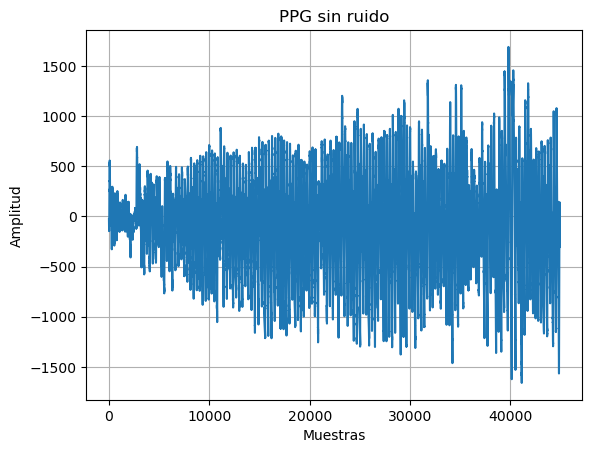

In [10]:
fs_ppg = 400  # Hz

ppg = np.load('ppg_sin_ruido.npy')

plt.figure()
plt.plot(ppg)
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.title('PPG sin ruido')
plt.grid()


Para la señal PPG también se compararon distintos valores de k con el objetivo de elegir una longitud de segmento adecuada para la estimación de la PSD.

In [11]:
N = len(ppg)

# k = 15
k1 = 15
l1 = N//k1

ventana1 = windows.flattop(l1)

f1, welch1 = sig.welch(ppg, fs=fs_ppg, window=ventana1, nperseg=l1, noverlap=l1//2, nfft=N)


# k = 20
k2 = 20
l2 = N//k2

ventana2 = windows.flattop(l2)

f2, welch2 = sig.welch(ppg, fs=fs_ppg, window=ventana2, nperseg=l2, noverlap=l2//2, nfft=N)


# k = 25
k3 = 25
l3 = N//k3

ventana3 = windows.flattop(l3)

f3, welch3 = sig.welch(ppg, fs=fs_ppg, window=ventana3, nperseg=l3, noverlap=l3//2, nfft=N)

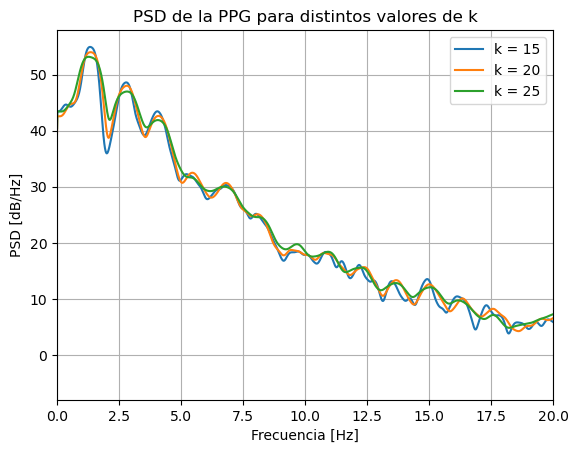

In [12]:
plt.figure()

plt.plot(f1, 10*np.log10(welch1), label='k = 15')
plt.plot(f2, 10*np.log10(welch2), label='k = 20')
plt.plot(f3, 10*np.log10(welch3), label='k = 25')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD de la PPG para distintos valores de k')

plt.xlim([0, 20])
plt.grid()
plt.legend()

Las tres estimaciones presentan un comportamiento similar. Se eligió k=20 ya que permite mantener un equilibrio entre el detalle del espectro y su suavizado.

(0.0, 50.0)

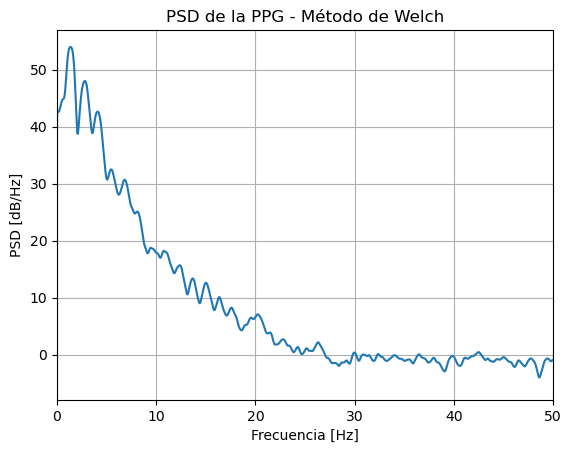

In [13]:
k = 20
l = N//k

ventana = windows.flattop(l)

f, welch_ppg = sig.welch(ppg, fs=fs_ppg, window=ventana, nperseg=l, noverlap=l//2, nfft=N)

plt.figure()
plt.plot(f, 10*np.log10(welch_ppg))

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD de la PPG - Método de Welch')

plt.grid()
plt.xlim([0, 50])

En la PSD se observa que la mayor parte de la potencia de la señal PPG se concentra en las bajas frecuencias y disminuye a medida que aumenta la frecuencia. Presentando entonces un comportamiento pasabajo.

In [33]:
pot_total_ppg = np.sum(welch_ppg)

pot_acum_ppg = np.cumsum(welch_ppg)

pot_acum_norm_ppg = pot_acum_ppg / pot_total_ppg

energia = 0.99

indice_BW_ppg = np.argmax(pot_acum_norm_ppg >= energia)

f_BW_ppg = f[indice_BW_ppg]

print('Ancho de banda de la PPG:', f_BW_ppg, 'Hz')

Ancho de banda de la PPG: 205.66666666666666 Hz


Considerando el 99 % de la potencia acumulada, se obtuvo para la señal PPG un ancho de banda aproximado de 5,49 Hz.

### Señales de audio

Ahora se analizarán las señales de audio disponibles, estimando su PSD mediante el método de Welch y posteriormente su ancho de banda.

#### Audio 1: La cucaracha

En primer lugar analizo el archivo `la cucaracha.wav`. Se observa primero la señal en el dominio temporal y también obtenemos la cantidad de muestras y la frecuencia de muestreo.

N = 144000
fs = 48000


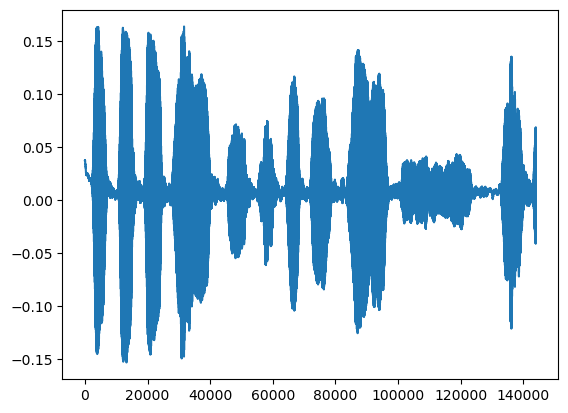

In [15]:
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
plt.figure()
plt.plot(wav_data)

N = len(wav_data)

print('N =', N)
print('fs =', fs_audio)

Para elegir la longitud de los segmentos comparé otra vez las estimaciones obtenidas para k=15, 20 y 25.

In [16]:
# k = 15
k1 = 15
l1 = N//k1

ventana1 = windows.flattop(l1)

f1, welch1 = sig.welch(wav_data, fs=fs_audio, window=ventana1, nperseg=l1, noverlap=l1//2, nfft=N)


# k = 20
k2 = 20
l2 = N//k2

ventana2 = windows.flattop(l2)

f2, welch2 = sig.welch(wav_data, fs=fs_audio, window=ventana2, nperseg=l2, noverlap=l2//2, nfft=N)

# k = 25
k3 = 25
l3 = N//k3

ventana3 = windows.flattop(l3)

f3, welch3 = sig.welch(wav_data, fs=fs_audio, window=ventana3, nperseg=l3, noverlap=l3//2, nfft=N)

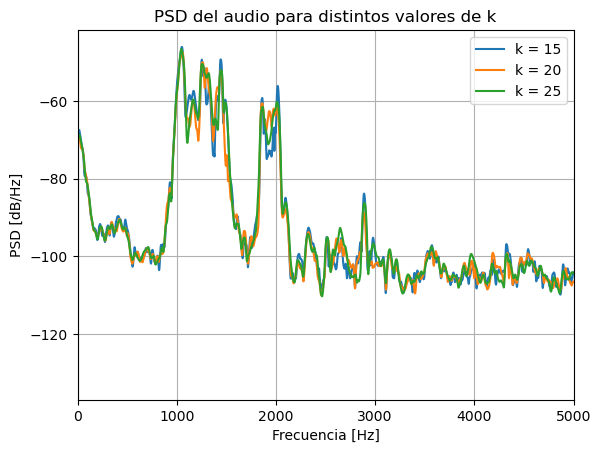

In [17]:
plt.figure()

plt.plot(f1, 10*np.log10(welch1), label='k = 15')
plt.plot(f2, 10*np.log10(welch2), label='k = 20')
plt.plot(f3, 10*np.log10(welch3), label='k = 25')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD del audio para distintos valores de k')

plt.xlim([0, 5000])
plt.grid()
plt.legend()
plt.show()

Para comparar los distintos valores de k se limitó la visualización del espectro entre 0 y 5000 Hz, ya que acá se encuentran las componentes de mayor potencia de la señal. Este límite solo modifica la visualización. A partir de la comparación se eligió k=20 como un valor intermedio entre el detalle y el suavizado del espectro.

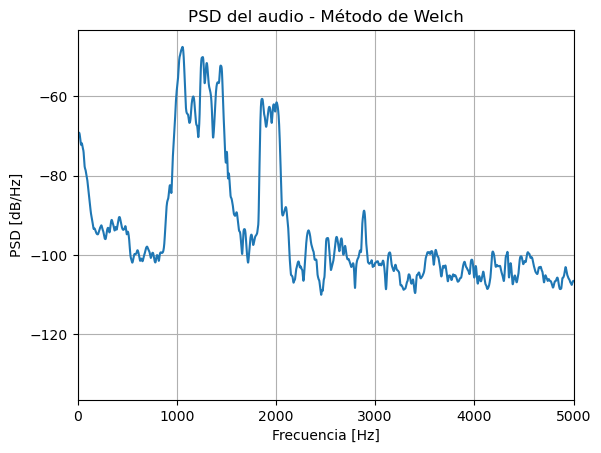

In [19]:
k = 20
l = N//k

ventana = windows.flattop(l)

f, welch_audio = sig.welch(wav_data, fs=fs_audio, window=ventana, nperseg=l, noverlap=l//2, nfft=N)

plt.figure()
plt.plot(f, 10*np.log10(welch_audio))

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD del audio - Método de Welch')
plt.grid()
plt.xlim([0, 5000])
plt.show()

En la PSD se observa que las componentes de mayor potencia se encuentran concentradas en una región de frecuencias alejada de 0 Hz. Por esto, para estimar el ancho de banda se considerará la señal como pasabanda, determinando una frecuencia inferior y una frecuencia superior.

In [21]:
pot_total_audio = np.sum(welch_audio)
pot_acum_audio = np.cumsum(welch_audio)
pot_acum_norm_audio = pot_acum_audio / pot_total_audio

indice_inf = np.argmax(pot_acum_norm_audio >= 0.005)
indice_sup = np.argmax(pot_acum_norm_audio >= 0.995)

f_inf = f[indice_inf]
f_sup = f[indice_sup]

BW_audio = f_sup - f_inf

print('Frecuencia inferior:', f_inf, 'Hz')
print('Frecuencia superior:', f_sup, 'Hz')
print('Ancho de banda del audio:', BW_audio, 'Hz')

Frecuencia inferior: 983.3333333333333 Hz
Frecuencia superior: 2015.0 Hz
Ancho de banda del audio: 1031.6666666666667 Hz


Considerando el 99 % de la potencia, se obtuvo una frecuencia inferior de 983,33 Hz y una frecuencia superior de 2015 Hz. Por lo tanto, el ancho de banda estimado de la señal es de aproximadamente 1031,67 Hz.

#### Audio 2: Prueba PSD

A continuación se analizará el archivo `prueba psd.wav` siguiendo el mismo procedimiento utilizado antes.

N = 144000
fs = 48000


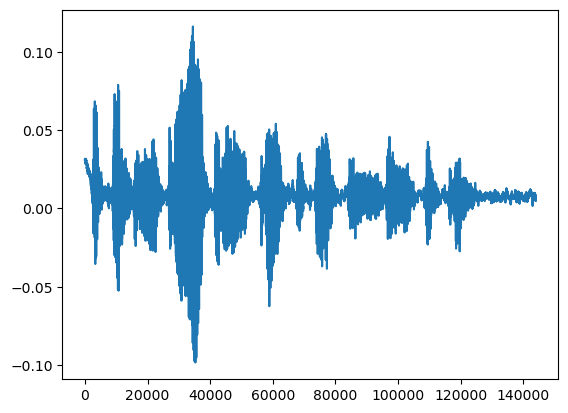

In [22]:
fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
plt.figure()
plt.plot(wav_data)

N = len(wav_data)

print('N =', N)
print('fs =', fs_audio)

Ahora hice el mismo procedimiento que antes, elijo la k adecuada para elegir la longitud de los segmentos que compararan las estimaciones de la PSD obtenidas.

In [23]:
# k = 15
k1 = 15
l1 = N//k1

ventana1 = windows.flattop(l1)

f1, welch1 = sig.welch(wav_data, fs=fs_audio, window=ventana1, nperseg=l1, noverlap=l1//2, nfft=N)


# k = 20
k2 = 20
l2 = N//k2

ventana2 = windows.flattop(l2)

f2, welch2 = sig.welch(wav_data, fs=fs_audio, window=ventana2, nperseg=l2, noverlap=l2//2, nfft=N)

# k = 25
k3 = 25
l3 = N//k3

ventana3 = windows.flattop(l3)

f3, welch3 = sig.welch(wav_data, fs=fs_audio, window=ventana3, nperseg=l3, noverlap=l3//2, nfft=N)

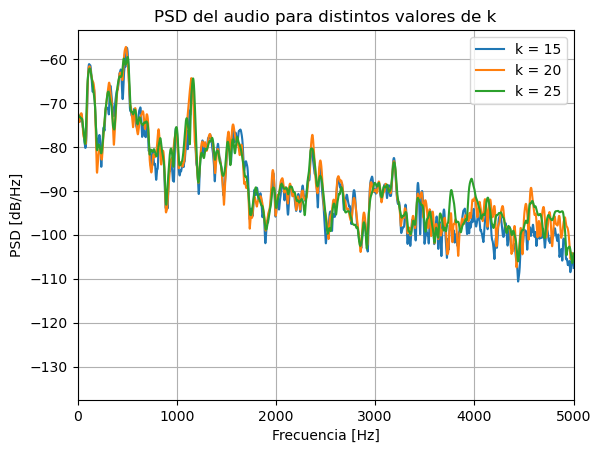

In [24]:
plt.figure()

plt.plot(f1, 10*np.log10(welch1), label='k = 15')
plt.plot(f2, 10*np.log10(welch2), label='k = 20')
plt.plot(f3, 10*np.log10(welch3), label='k = 25')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD del audio para distintos valores de k')

plt.xlim([0, 5000])
plt.grid()
plt.legend()
plt.show()

Sigo manteniendo K = 20 ya que permite mantener un equilibrio entre el detalle del espectro y el suavizado de la estimación.

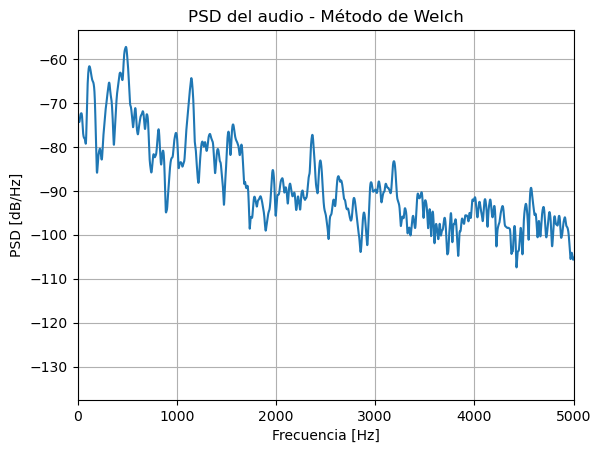

In [25]:
k = 20
l = N//k

ventana = windows.flattop(l)

f, welch_audio = sig.welch(wav_data, fs=fs_audio, window=ventana, nperseg=l, noverlap=l//2, nfft=N)

plt.figure()
plt.plot(f, 10*np.log10(welch_audio))

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD del audio - Método de Welch')
plt.grid()
plt.xlim([0, 5000])
plt.show()

En la PSD se observa que las componentes de mayor potencia se encuentran principalmente en las frecuencias bajas y que la potencia disminuye a medida que aumenta la frecuencia. Por este motivo, para estimar el ancho de banda se considera un comportamiento pasabajo.

In [26]:
pot_total_audio = np.sum(welch_audio)
pot_acum_audio = np.cumsum(welch_audio)
pot_acum_norm_audio = pot_acum_audio / pot_total_audio

energia = 0.99

indice_BW_audio = np.argmax(pot_acum_norm_audio >= energia)

f_BW_audio = f[indice_BW_audio]

print('Ancho de banda del audio:', f_BW_audio, 'Hz')

Ancho de banda del audio: 2385.6666666666665 Hz


A partir de la PSD se observó que la mayor parte de la potencia de la señal se encuentra concentrada en las bajas frecuencias, por lo que se consideró un comportamiento pasabajo. Tomando como criterio el 99 % de la potencia acumulada, se obtuvo un ancho de banda aproximado de 2385,67 Hz.

#### Audio 3: Silbido

Por último, se analizará el archivo `silbido.wav`, siguiendo el mismo procedimiento utilizado para las señales de audio anteriores.

N = 144000
fs = 48000


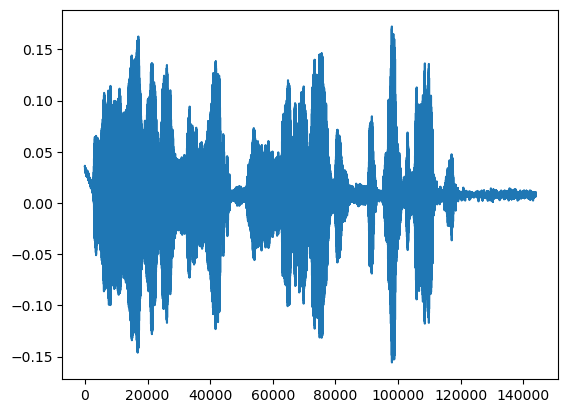

In [27]:
fs_audio, wav_data = sio.wavfile.read('silbido.wav')
plt.figure()
plt.plot(wav_data)

N = len(wav_data)

print('N =', N)
print('fs =', fs_audio)

In [28]:
# k = 15
k1 = 15
l1 = N//k1

ventana1 = windows.flattop(l1)

f1, welch1 = sig.welch(wav_data, fs=fs_audio, window=ventana1, nperseg=l1, noverlap=l1//2, nfft=N)


# k = 20
k2 = 20
l2 = N//k2

ventana2 = windows.flattop(l2)

f2, welch2 = sig.welch(wav_data, fs=fs_audio, window=ventana2, nperseg=l2, noverlap=l2//2, nfft=N)

# k = 25
k3 = 25
l3 = N//k3

ventana3 = windows.flattop(l3)

f3, welch3 = sig.welch(wav_data, fs=fs_audio, window=ventana3, nperseg=l3, noverlap=l3//2, nfft=N)

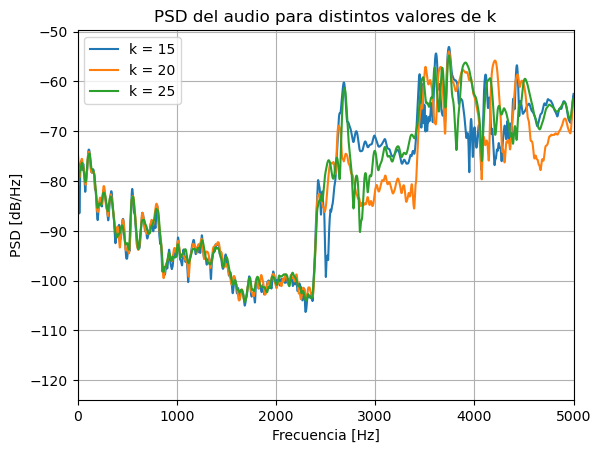

In [29]:
plt.figure()

plt.plot(f1, 10*np.log10(welch1), label='k = 15')
plt.plot(f2, 10*np.log10(welch2), label='k = 20')
plt.plot(f3, 10*np.log10(welch3), label='k = 25')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD del audio para distintos valores de k')

plt.xlim([0, 5000])
plt.grid()
plt.legend()
plt.show()

Se eligió nuevamente k=20 como un valor intermedio entre el detalle y el suavizado de la estimación.

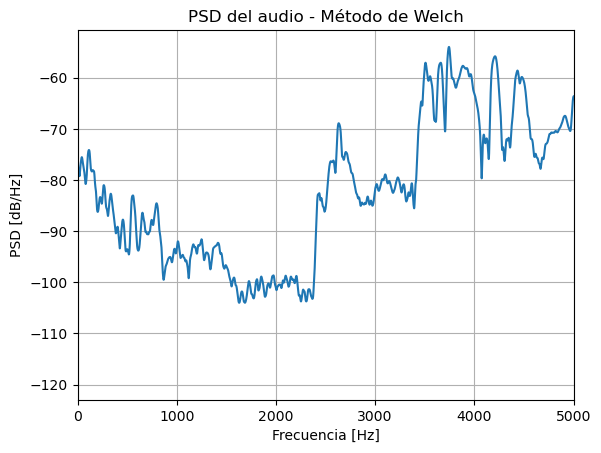

In [30]:
k = 20
l = N//k

ventana = windows.flattop(l)

f, welch_audio = sig.welch(wav_data, fs=fs_audio, window=ventana, nperseg=l, noverlap=l//2, nfft=N)

plt.figure()
plt.plot(f, 10*np.log10(welch_audio))

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.title('PSD del audio - Método de Welch')
plt.grid()
plt.xlim([0, 5000])
plt.show()

En la PSD se observa que las componentes de mayor potencia se encuentran concentradas en una región de frecuencias alejada de 0 Hz, como la del audio de ¨La cucaracha¨. Por esto, para estimar el ancho de banda se considerará la señal como pasabanda, determinando una frecuencia inferior y una frecuencia superior.

In [31]:
pot_total_audio = np.sum(welch_audio)
pot_acum_audio = np.cumsum(welch_audio)
pot_acum_norm_audio = pot_acum_audio / pot_total_audio

indice_inf = np.argmax(pot_acum_norm_audio >= 0.005)
indice_sup = np.argmax(pot_acum_norm_audio >= 0.995)

f_inf = f[indice_inf]
f_sup = f[indice_sup]

BW_audio = f_sup - f_inf

print('Frecuencia inferior:', f_inf, 'Hz')
print('Frecuencia superior:', f_sup, 'Hz')
print('Ancho de banda del audio:', BW_audio, 'Hz')

Frecuencia inferior: 2619.333333333333 Hz
Frecuencia superior: 6662.333333333333 Hz
Ancho de banda del audio: 4043.0 Hz


Considerando el 99 % de la potencia, se obtuvo una frecuencia inferior de 2619,33 Hz y una frecuencia superior de 6662,33 Hz. Por lo tanto, el ancho de banda estimado de la señal es de aproximadamente 4043 Hz.

### Conclusión

En esta tarea se utilizó el método de Welch para estimar la densidad espectral de potencia de distintas señales y analizar cómo se distribuye su potencia en frecuencia. A partir de las PSD obtenidas fue posible observar diferencias entre las señales: el ECG, la PPG y “Prueba PSD” presentaron la mayor parte de su potencia en las bajas frecuencias, mientras que en los audios “La cucaracha” y “Silbido” las componentes de mayor potencia se encontraron concentradas en regiones alejadas de 0 Hz. Finalmente, considerando el 99 % de la potencia como criterio, se estimó el ancho de banda de cada señal, permitiendo determinar el rango de frecuencias en el que se concentra la mayor parte de su contenido.